# Project Description:
**Understanding customer preferences and restaurant trends** is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights.
We aim to answer questions such as:

1. identify popular restaurant categories. (step-7)
2. Which restaurants are preferred by a larger number of individuals based on votes (step-8)
3. Find the restaurant with the highest number of votes. (step-9)
4. Exploring the online_order column to see how many restaurants accept online orders (step-10)
5. Analyze distribution of customer rating (step-11)
6. What price range do couples prefer for dining? (step-12)
7. Analyze customer ratings for Online vs Offline Orders (step-13)
8. Analyze order mode (online/offline) preference by restaurant type (step-14)

**Step 1:** Importing necessary Python libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2:**
*   Creating the data frame.
*   display all column names.
*   setting pandas display option to display all columns.
*   display top few lines of data.
*   display shape of data
















In [4]:

dataframe = pd.read_csv("zomato-data.csv")
print(dataframe.columns)
pd.set_option('display.max_columns', None)
print(dataframe.head(5))
print("Shape of dataset:",dataframe.shape)

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')
                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5  775.0   
1         Spice Elephant          Yes         No  4.1/5  787.0   
2        San Churro Cafe          Yes         No  3.8/5  918.0   
3  Addhuri Udupi Bhojana           No         No  3.7/5   88.0   
4          Grand Village           No         No  3.8/5  166.0   

   approx_cost(for two people) listed_in(type)  
0                        800.0          Buffet  
1                        800.0          Buffet  
2                        800.0          Buffet  
3                        300.0          Buffet  
4                        600.0          Buffet  
Shape of dataset: (148, 7)


**Step 3:** Data Cleaning and Preparation
Before moving further we need to clean and process the data.
1. Convert the rate column to a float by removing denominator characters.
dataframe['rate']=dataframe['rate'].apply(handleRate):
Applies the handleRate function to clean and convert each rating value in the
'rate' column.

In [5]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)

print("----------After cleaning rate column, printing top few records")
print(dataframe[['name','rate']].head())

----------After cleaning rate column, printing top few records
                    name  rate
0                  Jalsa   4.1
1         Spice Elephant   4.1
2        San Churro Cafe   3.8
3  Addhuri Udupi Bhojana   3.7
4          Grand Village   3.8


**Step 4:** Getting summary of the dataframe using df.info()
**Step 4.1:** Getting description of the dataframe using df.describe()

In [7]:
print("----------Dataset summary------------------")
dataframe.info()
print("----------Dataset description------------------")
print(dataframe.describe())

----------Dataset summary------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        144 non-null    float64
 5   approx_cost(for two people)  145 non-null    float64
 6   listed_in(type)              148 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.2+ KB
----------Dataset description------------------
             rate        votes  approx_cost(for two people)
count  148.000000   144.000000                   145.000000
mean     3.633108   265.729167                   415.517241
std      0.402271   662.490314                   2

**Step 5:** Checking for missing or null values to identify any data gaps (EDA)

In [8]:
print("---------Checking for missing or null values")
print(dataframe.isnull().sum())

---------Checking for missing or null values
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          4
approx_cost(for two people)    3
listed_in(type)                0
dtype: int64


**Step 6:** Handling missing data: filling gaps with mean value (Data Preparation)

In [9]:
df_cleaned = dataframe.fillna(dataframe.mean(numeric_only=True))
print("displaying null value count after handling missing data with mean value")
print(df_cleaned.isnull().sum())
dataframe = df_cleaned

displaying null value count after handling missing data with mean value
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


**step 6.1:** understanding spread of data
1. Visualize the spread of 'rate' using a Histogram


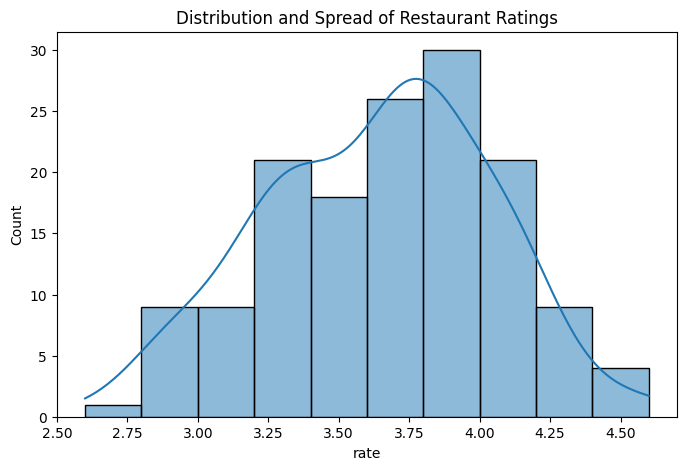

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(dataframe['rate'], bins=10, kde=True)
plt.title("Distribution and Spread of Restaurant Ratings")
plt.show()

**step 6.1:** understanding spread of data
2. Compare the spread of 'approx_cc' across 'online_or' categories using Box Plots

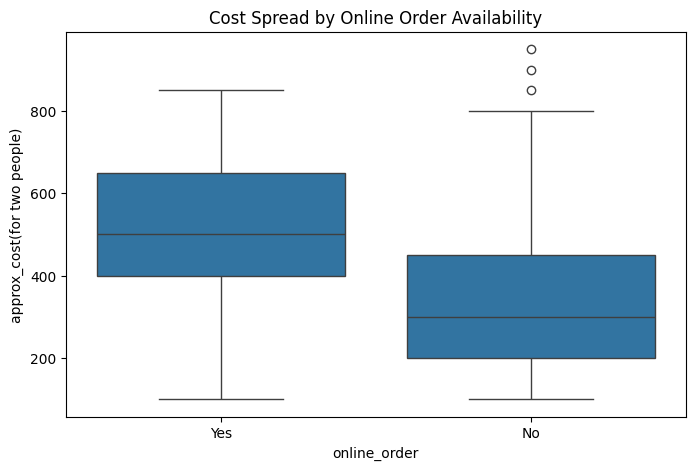

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='online_order', y='approx_cost(for two people)', data=dataframe)
plt.title("Cost Spread by Online Order Availability")
plt.show()

**Step 7:** Exploring Restaurant Types (EDA - Univariate Analysis)
countplot() using Seaborn is commonly used in EDA to visualize categorical data.
A countplot shows the count (frequency) of each unique category in a categorical variable using bars.


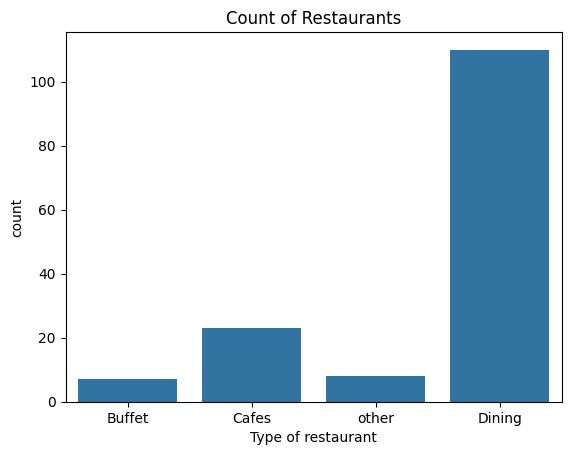

In [13]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.title("Count of Restaurants")
plt.xlabel("Type of restaurant")
plt.show()

**Step 8:** Exploring Votes by Restaurant Type (EDA - Bivariate Analysis)

listed_in(type)
Buffet     3028.000000
Cafes      6415.458333
Dining    20495.729167
other      9388.729167
Name: votes, dtype: float64
                        votes
listed_in(type)              
Buffet            3028.000000
Cafes             6415.458333
Dining           20495.729167
other             9388.729167


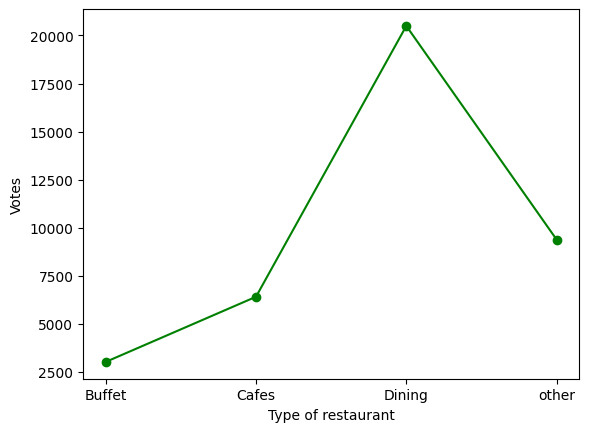

In [14]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
print(grouped_data)
result = pd.DataFrame({'votes': grouped_data})
print(result)
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.show()

**Step 9:** Identify the Most Voted Restaurant

In [15]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


**Step 10:** Online Order Availability

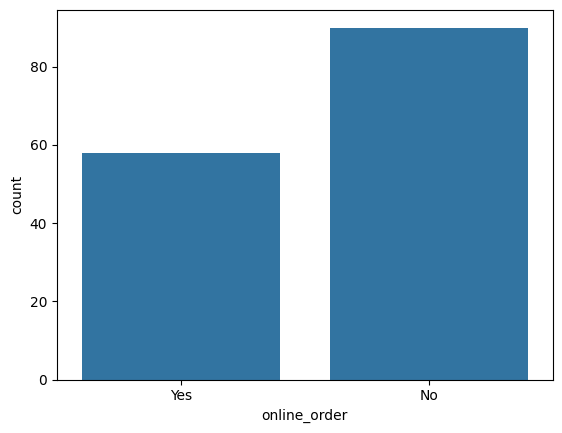

In [16]:
sns.countplot(x=dataframe['online_order'])
plt.show()

**Step 11:** Analyze customer Ratings

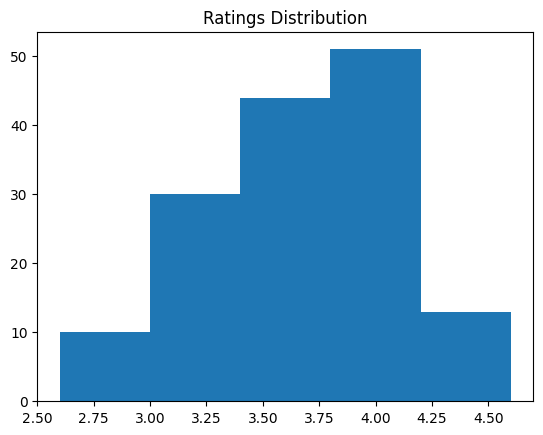

In [17]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

**Step 12:** Approximate Cost for Couples.
Analysing approx_cost(for two people) column to find the preferred price range

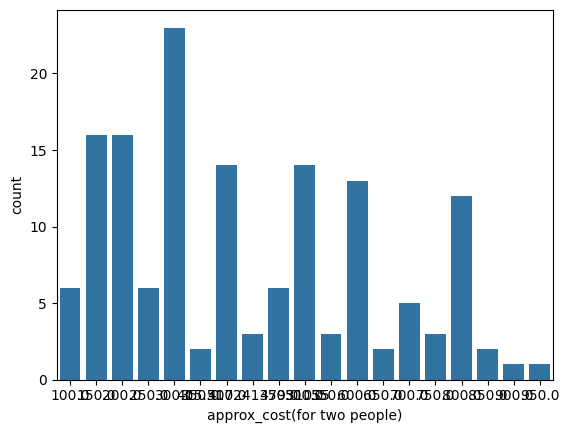

In [18]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)
plt.show()

**Step 13:** Ratings Comparison - Online vs Offline Orders

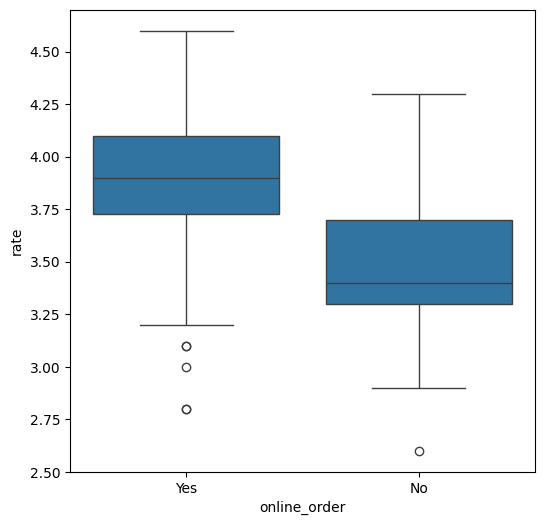

In [19]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)
plt.show()

**Step 14:** Order Mode Preferences by Restaurant Type

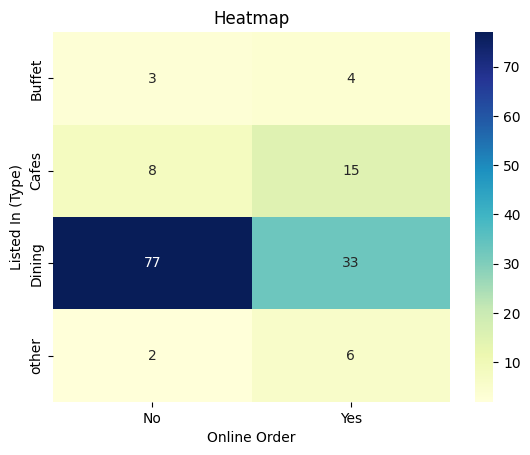

In [20]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

**Conclusion based on above heatmap** With this we can say that dining restaurants primarily receive offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.